# TiRex Foundation Model
In this notebook, we will show how to use TiRex in Darts. If you are new to Darts, please check out the [Quickstart Guide](https://unit8co.github.io/darts/quickstart/00-quickstart.html) before proceeding.

TiRex is a time series foundation model for zero-shot forecasting. That means that it can be used for forecasting **without any training or fine-tuning** since it has already been pre-trained on large-scale time series data. TiRex can produce probabilistic forecasts.

Check out the [NXAI TiRex Github Repo](https://github.com/NX-AI/tirex) and the [original paper](https://arxiv.org/abs/2505.23719) for technical details.

<div class="alert alert-success" role="alert">
  Fine-tuning TiRex on your own data is not supported in Darts.
</div>

In [1]:
# fix python path if working locally
from utils import fix_pythonpath_if_working_locally

fix_pythonpath_if_working_locally()
%matplotlib inline

In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [3]:
# use darts plotting style
from darts import set_option

set_option("plotting.use_darts_style", True)

In [4]:
import warnings

import numpy as np

from darts.datasets import ElectricityConsumptionZurichDataset
from darts.metrics import mae, mic, miw
from darts.models import TiRexModel
from darts.utils.likelihood_models import QuantileRegression

warnings.filterwarnings("ignore")
import logging

logging.disable(logging.CRITICAL)

/Users/lukas.fischer/.pyenv/versions/darts/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data Preparation

Here, we will use the [Electricity Consumption Zurich Dataset](https://unit8co.github.io/darts/generated_api/darts.datasets.datasets.html#darts.datasets.datasets.ElectricityConsumptionZurichDataset), which records the electricity consumption of households & SMEs (`"Value_NE5"` column) and business & services (`"Value_NE7"`) in Zurich, Switzerland, along with weather covariates such as temperature (`"T [°C]"`) and humidity (`"Hr [%Hr]"`).
Values are recorded every 15 minutes between January 2015 and August 2022.

<details>

<summary><strong>Train-Test Split</strong></summary>

Even though Chronos-2 is pre-trained already, we still need to split the data into training and test sets. That is because `Chronos2Model` follows the Darts unified interface and will require calling the `fit()` method before forecasting. However, no training or fine-tuning will be performed during the `fit()` call.

</details>

<details>

<summary><strong>Data Scaling</strong></summary>

Unlike other deep learning models in Darts, Chronos-2 does not require data scaling since it has its own internal data normalization mechanism. Therefore, we will skip the scaling step in this notebook.

</details>

In [5]:
# convert to float32 as Chronos-2 works with float32 input
data = ElectricityConsumptionZurichDataset().load().astype(np.float32)
# extract households energy consumption
ts_energy = data["Value_NE5"]
# extract temperature, solar irradiation and rain duration
ts_weather = data[["T [°C]", "StrGlo [W/m2]", "RainDur [min]"]]
# split into train and validation sets by last 7 days
train_energy, val_energy = ts_energy.split_before(len(ts_energy) - 7 * 24 * 4)

Let's quickly visualize the last 7 days of the electricity consumption data.

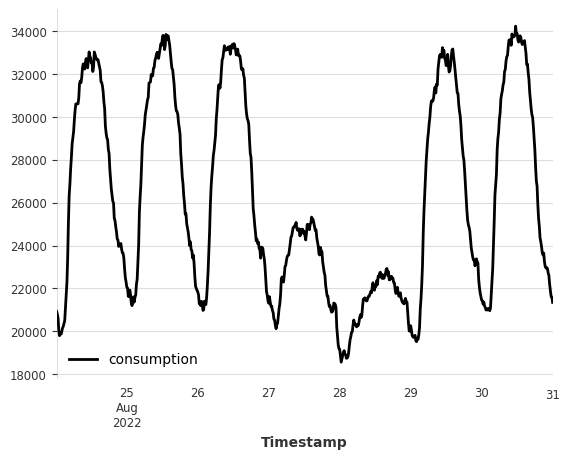

In [6]:
val_energy.plot(label="consumption");

## Model Creation

TiRex supports two types of forecasting outputs:
- **Deterministic** forecasts (**default**): single point estimates for each future time step.
- **Probabilistic** forecasts: multiple samples for each future time step, which can be used to estimate prediction intervals. To enable probabilistic forecasting, set `likelihood=QuantileRegression([...])` when creating the model. The list of quantiles used here must be a subset of TiRex supported quantiles: `[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]`.

<details>

<summary><strong>Model Downloading and Caching</strong></summary>

When creating a `TiRexModel` instance for the first time, the pre-trained model checkpoint will be automatically downloaded from [NX-AI/TiRex](https://huggingface.co/NX-AI/TiRex) hosted on Hugging Face Hub and cached locally. Subsequent usage of `TiRexModel` will NOT re-download the files but use the cached version instead.

If you would like to download or load the model checkpoint to a custom directory, set `local_dir` argument when creating the model. For example:

```python
model = TiRexModel(
    local_dir="path/to/your/directory"
)
```

</details>

In [11]:
# use last 30 days of data to predict next 7 days
model = TiRexModel(accept_license=True)

## Model Training
Here, we will call the `fit()` method to "train" the model on the training set. Note that no actual training or fine-tuning will be performed since TiRex is already pre-trained.

In [12]:
model.fit(
    series=train_energy,
    verbose=True,
)

TiRexModel(model_name=NX-AI/TiRex, likelihood=None, accept_license=True, device=None, backend=None, compile=None, add_encoders=None)

## Forecasting
We now perform a one-shot forecast for the next 7 days using TiRex. We then compare the forecast against the actual values from the validation set.

Predicting DataLoader 0: 100%|██████████| 1/1 [00:14<00:00,  0.07it/s]


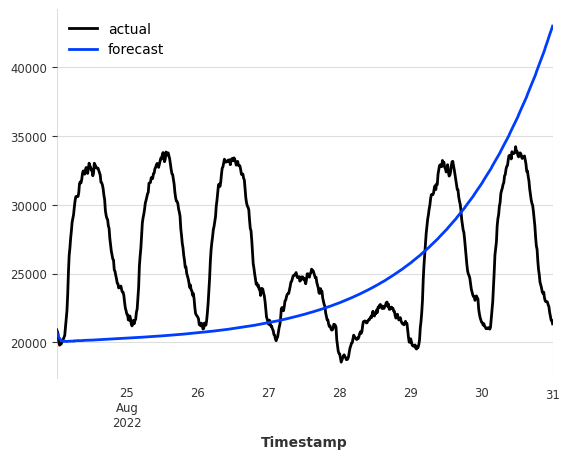

In [13]:
pred = model.predict(
    n=7 * 24 * 4,
    series=train_energy,
)
val_energy.plot(label="actual")
pred.plot(label="forecast");

You can see that TiRex is able to produce qualitatively accurate forecasts without any training or fine-tuning! Let's evaluate the forecast accuracy using the [Mean Absolute Error (MAE)](https://unit8co.github.io/darts/generated_api/darts.metrics.metrics.html#darts.metrics.metrics.mae) metric.

In [14]:
mae_val = mae(val_energy, pred)
print(f"MAE on validation set: {mae_val:.2f}")

MAE on validation set: 5718.72


## Probabilistic Forecasting
Here, we show how to perform probabilistic forecasting with TiRex by using [`QuantileRegression`](https://unit8co.github.io/darts/generated_api/darts.utils.likelihood_models.torch.html#darts.utils.likelihood_models.torch.QuantileRegression) likelihood. The quantiles passed to `QuantileRegression` must be a subset of pre-trained quantiles supported by TiRex (see "Model Creation" section above).

Because sampling with large models like TiRex can be computationally expensive, we here call `predict()` with `predict_likelihood_parameters=True` to obtain quantile estimates directly without sampling. However, if the forecast horizon is longer than `output_chunk_length` (i.e., auto-regressive forecasting is required), you must call `predict()` with a large enough `num_samples` value (e.g., 1000) to generate probabilistic forecasts via Monte Carlo sampling.

Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00,  3.57it/s]


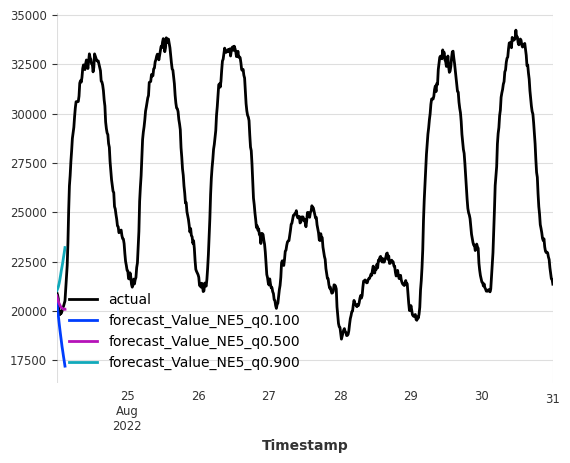

In [19]:
model = TiRexModel(
    accept_license=True,
    likelihood=QuantileRegression(quantiles=[0.1, 0.5, 0.9]),
)
model.fit(
    series=train_energy,
    verbose=True,
)
pred_prob = model.predict(
    n=12,
    series=train_energy,
    predict_likelihood_parameters=True,
)
val_energy.plot(label="actual")
pred_prob.plot(label="forecast");

For probabilistic forecasts, we can evaluate the forecast quality by computing the [Mean Interval Coverage (MIC)](https://unit8co.github.io/darts/generated_api/darts.metrics.metrics.html#darts.metrics.metrics.mic) (the share of actuals inside the prediction intervals) and [Mean Interval Width (MIW)](https://unit8co.github.io/darts/generated_api/darts.metrics.metrics.html#darts.metrics.metrics.miw) (the width of the prediction intervals) metrics to evaluate the quality of the prediction intervals.

For MIC, we expect a value close to the nominal coverage of the prediction intervals (i.e., 80% for the (0.1, 0.9) interval). For MIW, lower values indicate narrower prediction intervals and thus better forecast quality when MIC is satisfactory.

In [ ]:
mic_prob = mic(val_energy, pred_prob, q_interval=(0.1, 0.9))
miw_prob = miw(val_energy, pred_prob, q_interval=(0.1, 0.9))
print(f"MIC on validation set: {mic_prob:.2%}")
print(f"MIW on validation set: {miw_prob:.2f}")

MIC on validation set with covariates: 100.00%
MIW on validation set with covariates: 3256.07


## Final Remarks
Just like other Torch Forecasting Models in Darts, TiRex supports historical forecasting (`historical_forecasts()`), backtesting (`backtest()`), residual computation (`residuals()`), custom PyTorch Lightning arguments (`pl_trainer_kwargs`), and more. Check out the following resources to learn more about those topics:
- [Backtesting: simulate historical forecasting](https://unit8co.github.io/darts/quickstart/00-quickstart.html#Backtesting:-simulate-historical-forecasting)
- [Torch Forecasting Models User Guide](https://unit8co.github.io/darts/userguide/torch_forecasting_models.html)
- [Using Torch Models with GPUs and TPUs](https://unit8co.github.io/darts/userguide/gpu_and_tpu_usage.html)
- [TiRex Model API](https://unit8co.github.io/darts/generated_api/darts.models.forecasting.tirex_model.html)